# Loading and displaying color images

## Download onto Google Colab

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1Lq8ZZhY5q1xUH1sZ9djoWLPZ8Hdj0Gen"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "greyscalefruits.png", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1Lq8ZZhY5q1xUH1sZ9djoWLPZ8Hdj0Gen
To: /content/greyscalefruits.png
100%|██████████| 157k/157k [00:00<00:00, 33.8MB/s]


'greyscalefruits.png'

#OpenCV

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

OpenCV χρησιμοποιεί BGR image format.  [See more](https://www.geeksforgeeks.org/convert-bgr-and-rgb-with-python-opencv/)


OpenCV διαβάζει τις εικόνες σε BGR format (αντί για RGB). [See more](https://stackoverflow.com/questions/14556545/why-opencv-using-bgr-colour-space-instead-of-rgb)


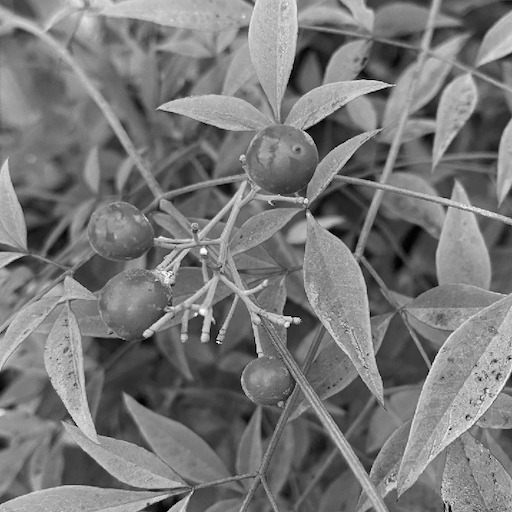

In [ ]:
image = cv2.imread('greyscalefruits.png')
X = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(X)

### Εμφάνιση βασικών πληροφοριών
##### shape: (height, width, channels)
##### dtype: ο τύπος των δεδομένων (π.χ. uint8)
##### size: ο συνολικός αριθμός pixels (height * width * channels)

In [ ]:
#X = cv2.imread('fruits_greyscale.png')
#print(X)
height, width = X.shape
print(f"Σχήμα (shape) εικόνας: {imrgb.shape} -> (Ύψος={height}, Πλάτος={width})")
print(f"Τύπος δεδομένων (dtype): {imrgb.dtype}")
print(f"Συνολικό πλήθος στοιχείων (pixels * κανάλια): {imrgb.size}")

Σχήμα (shape) εικόνας: (512, 512, 3) -> (Ύψος=512, Πλάτος=512)
Τύπος δεδομένων (dtype): uint8
Συνολικό πλήθος στοιχείων (pixels * κανάλια): 786432


#### Υπολογισμός μέσου όρου φωτεινότητας της εικόνας

In [ ]:
import numpy as np
rows, cols = X.shape

# 1a. Με χρήση 2 βρόγχων for (nested loops)
total = 0
for i in range(rows):
    for j in range(cols):
        total += X[i, j]
avg_loop = total / (rows * cols)
print("Μέσος όρος φωτεινότητας (βρόχοι for):", avg_loop)

# 1b. Με χρήση της συνάρτησης μέσου όρου της Matlab (εδώ np.mean)
avg_np = np.mean(X)
print("Μέσος όρος φωτεινότητας (np.mean):%.1f", avg_np)

Μέσος όρος φωτεινότητας (βρόχοι for): 119.9308090209961
Μέσος όρος φωτεινότητας (np.mean): 119.9308090209961


In [ ]:
variance_sum = 0
for i in range(rows):
    for j in range(cols):
        variance_sum += (X[i, j] - avg_loop) ** 2
std_loop = np.sqrt(variance_sum / (rows * cols))
print("Τυπική απόκλιση (βρόχοι for):", std_loop)

# 2b. Με χρήση της συνάρτησης std (όπως Matlab std)
std_np = np.std(X)
print("Τυπική απόκλιση (np.std):", std_np)

# Σχόλιο: Μια υψηλή τιμή τυπικής απόκλισης σημαίνει μεγάλη διακύμανση στις τιμές φωτεινότητας,
# δηλαδή η εικόνα έχει υψηλή αντίθεση ή πολλές διαφοροποιημένες περιοχές φωτεινότητας.
# Αν η τιμή είναι χαμηλή, οι τιμές είναι πιο ομοιόμορφες.

Τυπική απόκλιση (βρόχοι for): 42.82667451704034
Τυπική απόκλιση (np.std): 42.82667451710293


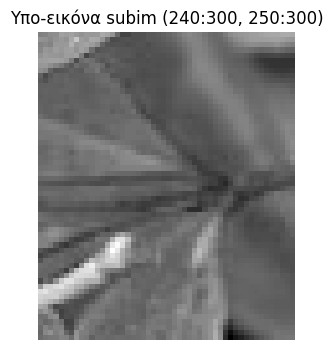

In [ ]:
# Σημείωση: Στην Python η αρίθμηση ξεκινά από το 0, αλλά εδώ χρησιμοποιούμε τους δείκτες
# όπως δίνονται στην εκφώνηση (240:300, 250:300) που θα δώσουν περιοχή 240 έως 299 και 250 έως 299.
subim = X[240:300, 250:300]

# 3a. Εμφάνιση της μεταβλητής subim
plt.figure(figsize=(4,4))
plt.imshow(subim, cmap='gray')
plt.title("Υπο-εικόνα subim (240:300, 250:300)")
plt.axis('off')
plt.show()

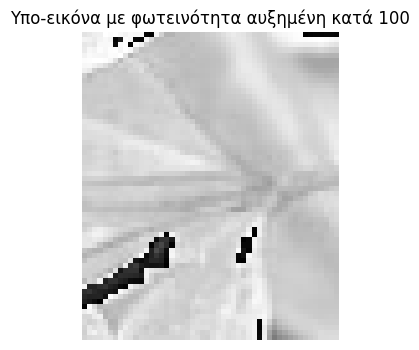

Κλείστηκαν όλες οι εικόνες.


In [ ]:
# 3b. Αύξηση της φωτεινότητας της περιοχής κατά 100 (με αποκοπή στο 255)
subim_brighter = np.clip(subim + 100, 0, 255).astype(np.uint8)
plt.figure(figsize=(4,4))
plt.imshow(subim_brighter, cmap='gray')
plt.title("Υπο-εικόνα με φωτεινότητα αυξημένη κατά 100")
plt.axis('off')
plt.show()

In [ ]:
max_brightness = np.max(X)
min_brightness = np.min(X)
print("Μέγιστη φωτεινότητα:", max_brightness)
print("Ελάχιστη φωτεινότητα:", min_brightness)

Μέγιστη φωτεινότητα: 255
Ελάχιστη φωτεινότητα: 0
Κλείστηκαν όλες οι εικόνες.


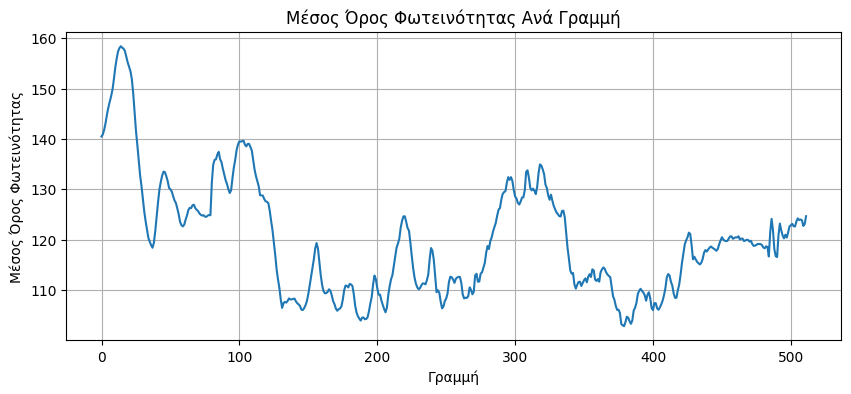

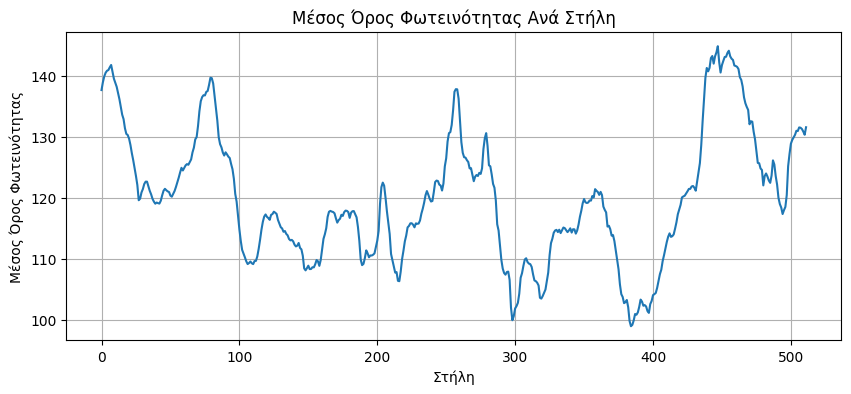

In [ ]:
mean_per_row = np.mean(X, axis=1)
mean_per_col = np.mean(X, axis=0)

# Εμφάνιση μέσου όρου ανά γραμμή
plt.figure(figsize=(10, 4))
plt.plot(mean_per_row)
plt.title("Μέσος Όρος Φωτεινότητας Ανά Γραμμή")
plt.xlabel("Γραμμή")
plt.ylabel("Μέσος Όρος Φωτεινότητας")
plt.grid(True)
plt.show()

# Εμφάνιση μέσου όρου ανά στήλη
plt.figure(figsize=(10, 4))
plt.plot(mean_per_col)
plt.title("Μέσος Όρος Φωτεινότητας Ανά Στήλη")
plt.xlabel("Στήλη")
plt.ylabel("Μέσος Όρος Φωτεινότητας")
plt.grid(True)
plt.show()


# Matplotlib

In [ ]:
import matplotlib.pyplot as plt

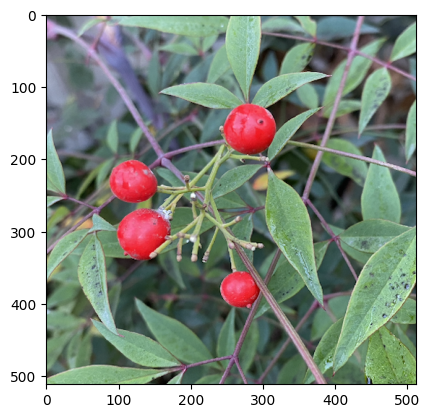

In [ ]:
X = plt.imread('fruits.png')
plt.imshow(X)
plt.show()

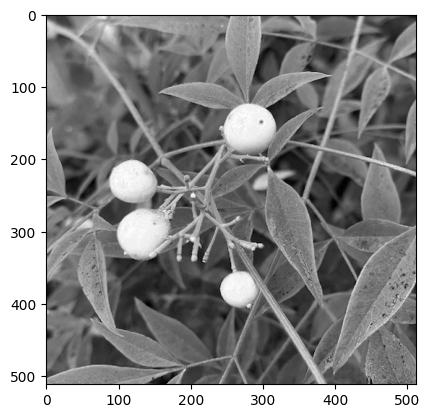

In [ ]:
# Red channel
R = X[:,:,0]
plt.imshow(R,cmap='gray')
plt.show()

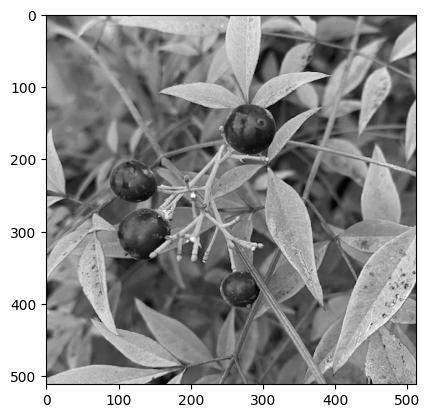

In [ ]:
# Green color
G = X[:,:,1]
plt.imshow(G,cmap='gray')
plt.show()

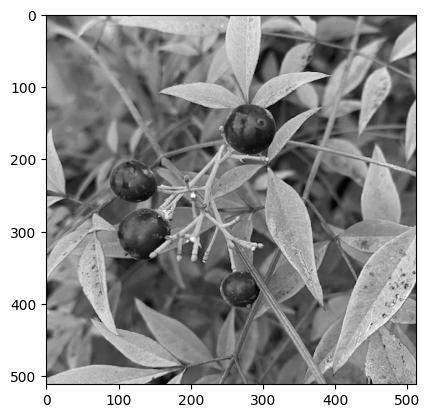

In [ ]:
# Blue channel
B = X[:,:,1]
plt.imshow(B,cmap='gray')
plt.show()

# OpenCV y Matplotlib

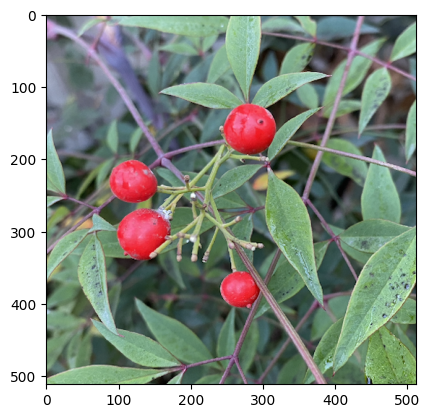

In [ ]:
Xbgr = cv2.imread('frutos_rojos.png')
Xrgb = cv2.cvtColor(Xbgr, cv2.COLOR_BGR2RGB) # conversion BGR to RGB
plt.imshow(Xrgb)
plt.show()

# Γείτονες

Γειτονικοί pixels για τη θέση (row=256, col=256):

[[[ 76 114  76]
  [ 78 114  78]
  [ 85 120  86]]

 [[ 74 109  70]
  [ 76 111  73]
  [ 86 121  85]]

 [[ 84 119  78]
  [ 82 117  76]
  [ 84 119  80]]]


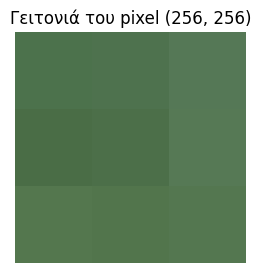

In [ ]:
def print_pixel_neighbors(image, row, col):
    """
    Εκτυπώνει τους γειτονικούς pixels γύρω από τη θέση (row, col).
    Θεωρούμε ένα παράθυρο 3x3 γύρω από αυτό το pixel (8-γειτονιά).
    """

    # Λαμβάνουμε τις διαστάσεις της εικόνας
    h, w, c = image.shape

    # Για να αποφύγουμε out of range λάθη, ορίζουμε τα όρια [row-1, row+1], [col-1, col+1]
    # Κάνουμε clamp στα επιτρεπτά όρια (0, h-1) και (0, w-1).
    r_min = max(row - 1, 0)
    r_max = min(row + 1, h - 1)
    c_min = max(col - 1, 0)
    c_max = min(col + 1, w - 1)

    # Εμφανίζουμε τον πίνακα των γειτονικών pixels
    neighbor_region = image[r_min:r_max+1, c_min:c_max+1, :]

    print(f"Γειτονικοί pixels για τη θέση (row={row}, col={col}):\n")
    # Εμφανίζουμε τις τιμές σε μορφή πίνακα
    print(neighbor_region)

    # Προαιρετικά: μπορούμε να εμφανίσουμε την υπο-εικόνα
    plt.figure(figsize=(3,3))
    plt.imshow(neighbor_region)
    plt.axis('off')
    plt.title(f"Γειτονιά του pixel ({row}, {col})")
    plt.show()
imrgb = cv2.cvtColor(X, cv2.COLOR_BGR2RGB)
# Παράδειγμα χρήσης της print_pixel_neighbors
# Μπορείτε να αλλάξετε τις τιμές row, col για να δείτε διαφορετικά σημεία στην εικόνα.
test_row, test_col = height // 2, width // 2  # Κεντρικό pixel
print_pixel_neighbors(imrgb, test_row, test_col)